<a href="https://colab.research.google.com/github/T1toh/30Days_of_SQL/blob/main/MODULE_3_%7C_LESSON_2_Advanced_Credit_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAPSTONE REVIEW**
## MODULE 3 | LESSON 2: Advanced Credit Applications
---

| | |
|:---|:---|
|**Reading Time** | 4h |
|**Prior Knowledge** | derivatives pricing, stochastic processes, credit risk fundamentals, copula theory basics, regression analysis, Monte Carlo simulation |
|**Keywords** | counterparty risk, CVA, wrong-way risk, credit correlation, default dependence, copulas, correlation matrix reduction, bootstrapping, quantile regression, XVA |

---

## **Introduction**

In the world of modern finance, counterparty risk is like termites in your house – invisible until the structure collapses, and by then it's too late. We saw this spectacularly in 2008. Before the crisis, derivatives traders lived in a fantasy land where everyone assumed their counterparties were immortal (why did we believe this?). The rude awakening transformed how we think about credit risk in derivatives markets.

This lesson takes you deep into the machinery of advanced credit applications. We start with counterparty risk – the risk that your trading partner vanishes along with the money they owe you. From there, we'll build up to Credit Value Adjustment (CVA), which is essentially the market's way of pricing in the possibility that your counterparty might default. It pays to understand these frameworks thoroughly – they've become as fundamental to derivatives trading as Black-Scholes.

Note that we're not just covering theory here. We'll explore wrong-way risk through copula theory (think of it as modeling how bad things tend to happen together), investigate the thorny problem of credit correlation, and tackle the computational nightmares that arise when dealing with thousands of counterparties. By the end, you'll understand how quantile regression helps banks figure out how much capital they need to survive the next crisis.

## **1. Counterparty Risk in Derivatives Markets**

### **1.1 Fundamentals of Counterparty Risk**

Counterparty risk in derivatives is peculiar – it's a moving target that can swing from friend to foe in milliseconds. Think about it this way. When you lend someone money, you know exactly what you might lose. But with derivatives? The exposure dances around like a flame in the wind, driven by every tick in the market.

A bit more precisely, counterparty risk represents the possibility that the entity on the other side of your derivative contract will default before fulfilling their obligations. What makes this risk special (and especially nasty) is its bilateral nature. Unlike a loan where only the lender faces credit risk, derivatives create a two-way street – either party might end up owing the other, depending on how markets move.

It pays to examine a concrete example. Imagine you've entered an interest rate swap where you receive fixed and pay floating. Interest rates plummet. Suddenly your counterparty owes you substantial amounts (why?). If they default now, you don't just lose today's mark-to-market value – you lose all those juicy future fixed payments you were expecting. The 2008 crisis turned this theoretical risk into brutal reality when even AAA-rated institutions teetered on the edge of collapse.

### **1.2 Measuring Counterparty Exposure**

Measuring counterparty exposure requires a whole arsenal of metrics – each capturing different aspects of this shape-shifting risk. Let's work through them systematically.

**Current Exposure (CE)** is the simplest: if your counterparty defaulted right now, what would you lose? Mathematically, it's just:
$$CE(t) = \max(V(t), 0)$$
where $V(t)$ represents your position's mark-to-market value. Note the max function – if you owe them money (negative $V(t)$), your exposure is zero (though theirs isn't!).

But current exposure tells you nothing about tomorrow. That's where **Expected Exposure (EE)** comes in:
$$EE(t) = E[\max(V(t), 0)]$$
This requires Monte Carlo simulation – you must model thousands of possible future market scenarios and calculate your average exposure across them all.

Risk managers often prefer a single number to track. Enter **Expected Positive Exposure (EPE)**:
$$EPE = \frac{1}{T}\int_0^T EE(t)dt$$
Think of EPE as your average expected exposure over the contract's life – it's particularly useful for regulatory capital calculations (why would regulators care about averages?).

Finally, there's **Potential Future Exposure (PFE)** – the pessimist's metric. PFE typically represents the 95th or 99th percentile of future exposure. It answers: "How bad could this get under reasonably extreme conditions?" Note that we say "reasonably extreme" – true tail events require different tools entirely.

## **2. Credit Value Adjustment (CVA) Frameworks**

### **2.1 The CVA Paradigm Shift**

Before 2008, pricing derivatives without considering counterparty risk was like driving without insurance – it worked fine until it didn't. The crisis shattered this comfortable delusion. CVA emerged from the wreckage as the new standard for pricing counterparty credit risk into every trade.

CVA is beautifully simple in concept: it's the price of counterparty risk. More precisely, CVA equals the difference between your derivative's risk-free value and its value accounting for potential counterparty default. The canonical formula reads:
$$CVA = (1-R) \int_0^T EE(t) \cdot PD(0,t) \cdot DF(0,t) dt$$

Let's dissect this formula carefully. The $(1-R)$ term represents your loss given default – if recovery is 40%, you lose 60%. The integral sweeps across time, at each point multiplying three crucial ingredients: how much they might owe you ($EE(t)$), the probability they default precisely then ($PD(0,t)$), and the present value factor ($DF(0,t)$). Notice what we're assuming here – that exposure and default probability are independent (spoiler: they're often not).

It pays to think about CVA from a trader's perspective. Every time you trade a derivative, you're simultaneously trading the underlying risk and buying credit protection on your counterparty. CVA prices that embedded credit protection. No wonder banks created entire CVA desks to manage this risk centrally!

### **2.2 Practical CVA Implementation**

Implementing CVA in practice is where elegant theory meets messy reality. You need industrial-strength infrastructure to make it work.

First comes the **Exposure Simulation Engine** – the computational beast at CVA's heart. This Monte Carlo framework must simulate thousands of market scenarios across multiple time steps. For each scenario and time point, it revalues every derivative in your portfolio (why every derivative?). Complex trades with early exercise features or path-dependence turn this into a computational marathon. Banks spend millions on computing clusters just to keep these calculations running overnight.

Next, you need **Credit Spread Curves** to extract default probabilities. The market speaks through credit default swap spreads and bond prices – your job is to listen. As we explored in FD Module 5, these spreads embed the market's collective wisdom about default risk. But here's the rub: many counterparties don't have liquid CDS trading. You're forced to use proxy curves, mapping your local municipality to sovereign spreads (how comfortable does that make you feel?).

Don't forget **Netting and Collateral Modeling**. Legal agreements dramatically reduce exposure – netting lets positive and negative values offset, while collateral agreements require posting margin. But modeling these agreements accurately is fiendish. When do margin calls happen? How long before collateral arrives? What haircuts apply? Miss these details and your CVA is fantasy.

Finally, risk management demands **CVA Sensitivities**. CVA desks must hedge their exposure, which requires understanding how CVA responds to market moves:
- Credit Delta: When spreads widen, how much does CVA increase?
- IR Delta: Rate changes affect both exposure and discounting
- Cross-Gamma: The wicked second-order effects when multiple risks move together

Note that these sensitivities often behave counterintuitively. Rising rates might decrease CVA on a receiver swap (why?), creating natural hedges you'd miss without careful analysis.

## **3. Wrong-Way Risk Identification Using Copula Theory**

### **3.1 Understanding Wrong-Way Risk**

Wrong-way risk (WWR) is the market's cruel joke – it ensures that your counterparty is most likely to default precisely when they owe you the most. It's Murphy's Law weaponized for derivatives.

Think about an oil producer hedging with commodity swaps. Oil prices crash. The producer now owes massive amounts on their hedges just as their revenue evaporates and credit quality crumbles. That's wrong-way risk in action – exposure and credit quality moving in lockstep toward disaster. The opposite phenomenon, right-way risk (where exposure shrinks as credit deteriorates), is rarer than hen's teeth in practice.

A bit more precisely, WWR occurs when the correlation between exposure and default probability is positive. This correlation transforms CVA from a mere pricing adjustment into a potential portfolio killer. Studies suggest WWR can double or triple CVA – yet many banks still struggle to model it properly (why might that be?).

### **3.2 Copula-Based WWR Modeling**

Copulas offer an elegant framework for capturing the dependence between exposure and default – they're like the connective tissue linking these two risk dimensions. The beauty of copulas lies in their separation of dependence structure from marginal behaviors.

The **Gaussian Copula** remains popular despite its starring role in the CDO debacle:
$$C^{Gauss}(u,v;\rho) = \Phi_2(\Phi^{-1}(u), \Phi^{-1}(v); \rho)$$
Here $\rho$ captures linear correlation – positive values create wrong-way risk. But Gaussian copulas assume symmetric dependence, missing the crucial fact that extreme events often correlate more strongly than normal ones.

Enter the **Student-t Copula**:
$$C^t(u,v;\rho,\nu) = t_2(t_\nu^{-1}(u), t_\nu^{-1}(v); \rho, \nu)$$
That extra parameter $\nu$ (degrees of freedom) controls tail dependence – lower values mean extreme events cluster together more. It's like adjusting the "crisis correlation" dial.

For asymmetric situations, **Archimedean Copulas** shine. Clayton copulas capture lower tail dependence (both variables crash together), while Gumbel focuses on upper tails. Your choice depends on the risk story – is disaster correlation stronger than success correlation?

It pays to understand the implementation mechanics:
1. Run your standard exposure Monte Carlo simulation
2. Model default timing using stochastic intensity (CIR or similar)
3. Connect exposure and default intensity through your chosen copula
4. Recompute CVA with this dependence baked in

The results can be shocking. That oil producer hedge? Standard CVA might be 2% of notional, but with strong WWR modeled via Student-t copula, it jumps to 5% or more.

## **4. Credit Correlation and Default Dependence**

### **4.1 The Correlation Challenge**

Credit correlation is the invisible force that transforms a diversified portfolio into a house of cards during crisis. It measures how defaults cluster – and cluster they do, with a vengeance unimaginable in calm markets.

Here's the fundamental challenge: we observe defaults rarely (thankfully!), making correlation estimation a statistical nightmare. Imagine estimating correlation between two events that each happen 1% of the time – you'd need centuries of data! So we resort to shortcuts and models, each with its own pitfalls.

**Asset Correlation** offers one path forward. Following Merton's insight, we model firms as defaulting when their asset value drops below debt. Asset returns correlate more observably than defaults, giving us data to work with. But here's the kicker – a 30% asset correlation might translate to only 5% default correlation for investment-grade names (why such a dramatic difference?). The mapping is viciously non-linear and rating-dependent.

Don't forget **Correlation Dynamics** – the nastiest feature of credit markets. Correlations spike precisely when you need diversification most. That carefully constructed portfolio with 20% average pair correlation? Watch it jump to 60% when crisis hits. This pro-cyclicality isn't a bug; it's a feature of how credit markets work.

### **4.2 Modeling Default Dependence**

Several frameworks compete to capture default dependence, each with distinct advantages and blind spots.

**Factor Models** decompose firm asset values into systematic and idiosyncratic components:
$$X_i = \sqrt{\rho_i}Z + \sqrt{1-\rho_i}\epsilon_i$$
The systematic factor $Z$ drives correlation – when it tanks, everyone suffers together. The beauty lies in its simplicity: one parameter ($\rho_i$) captures each firm's correlation with the system. But which factor? Global equity? Regional GDP? Industry indices? Your choice dramatically affects results.

**Copula Models** extend beyond the two-dimensional WWR case to capture portfolio-wide dependence. Vine copulas let you build complex structures from simple building blocks – like molecular chemistry for correlation. But beware: with great flexibility comes great parameter uncertainty.

Note how these models behave differently for structured products. In CDO tranches, correlation assumptions literally make or break values. Low correlation? Equity tranches suffer while seniors coast. High correlation? The opposite occurs – seniors face cliff risk while equity enjoys lottery-like payoffs (can you see why?).

**Contagion Models** add network effects – one default triggering others like dominoes. These models capture the "Irish bank" phenomenon where institutions are "sound separately but fragile together." Implementation requires mapping the web of interbank exposures, trade relationships, and confidence channels through which contagion spreads.

## **5. Computational Methods: Dimension Reduction for Correlation Matrices**

### **5.1 The Curse of Dimensionality**

Large banks face a combinatorial explosion when modeling credit correlations. Consider a modest 1,000-name portfolio. That's 499,500 unique correlations to estimate! With perhaps 10 years of daily data (2,500 observations), you have 5 data points per parameter – a statistical impossibility.

Worse yet, empirical correlation matrices often misbehave mathematically. Negative eigenvalues appear, making the matrix non-positive-definite and causing numerical methods to explode. It's like trying to take the square root of a negative number – mathematically forbidden and computationally catastrophic.

### **5.2 Principal Component Analysis (PCA)**

PCA rides to the rescue by finding the market's hidden drivers – the puppet strings that make credits dance together. The mathematics is elegant:
$$\Sigma = V\Lambda V^T$$
Eigenvectors in $V$ represent market factors; eigenvalues in $\Lambda$ tell you their importance.

It pays to follow the implementation recipe carefully:
1. Calculate the empirical correlation matrix from credit spread changes (why changes, not levels?)
2. Compute eigenvalues and eigenvectors – numerical libraries make this painless
3. Sort by eigenvalue magnitude and truncate – typically 10-50 factors capture 95%+ of variance
4. Reconstruct: $\tilde{\Sigma} = V_k\Lambda_k V_k^T$ using only top $k$ components

The results are striking. Those 499,500 correlations? Often 20 factors suffice, a 25,000-fold reduction! The leading factors usually have clear interpretations – global credit, regional effects, industry dynamics.

### **5.3 Random Matrix Theory (RMT) Filtering**

But wait – how many of those factors are real versus statistical noise? Random Matrix Theory provides a noise detector for correlation matrices. The idea is brilliant: compare your eigenvalues to what pure noise would produce.

The Marchenko-Pastur distribution describes noise eigenvalues:
$$\rho_{MP}(\lambda) = \frac{1}{2\pi\sigma^2\lambda\gamma}\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}$$

Here's the key insight: eigenvalues above $\lambda_+ = \sigma^2(1 + \sqrt{\gamma})^2$ represent genuine market factors. Those below? Statistical mirages that vanish with different data samples. For typical credit portfolios, RMT filtering removes 90%+ of eigenvalues as noise (sobering, isn't it?).

Note how this changes risk calculations. Using the full noisy matrix often overstates diversification benefits. RMT-filtered matrices produce more conservative, stable risk estimates – exactly what you want when markets turn ugly.

## **6. Stressed Credit Scenarios via Bootstrapping Methods**

### **6.1 The Need for Stress Testing**

Regulators learned a painful lesson in 2008: normal market risk models fail spectacularly in crises. Now they demand stress tests – explorations of "what if" scenarios that push portfolios to breaking points. But here's the challenge: how do you stress test for a crisis you've never seen?

Historical episodes provide templates – the 2008 meltdown, the European sovereign crisis, the Asian contagion. Yet each crisis brings novel features. Who anticipated negative oil prices in 2020? Bootstrapping offers a flexible framework for generating plausible yet severe scenarios that respect historical patterns while allowing for innovation.

### **6.2 Bootstrap Methods for Stress Scenarios**

**Block Bootstrap for Time Series** preserves the crucial temporal dependencies in credit markets. Default waves don't happen in independent daily doses – they cluster in episodes.

The implementation recipe:
1. Choose block length capturing crisis dynamics (typically 20-60 days)
2. Oversample from stressed periods – if crisis days were 5% of history, sample them 25% of the time
3. Stitch blocks together maintaining cross-sectional correlation within blocks

This approach generates scenarios with realistic persistence. A single bad day doesn't constitute a crisis – it's the relentless accumulation that breaks portfolios.

**Conditional Bootstrap** targets specific stress conditions. Want to test vulnerability to investment-grade downgrades? Follow these steps:
1. Identify historical periods with IG→HY migrations above the 90th percentile
2. Bootstrap exclusively from these conditional periods
3. Scale if needed – if history peaked at 3% downgrades but you want to test 5%, apply multiplicative scaling

**Importance Sampling Bootstrap** tilts toward tail events mathematically:
$$p_i^* = \frac{p_i \cdot w_i}{\sum_j p_j \cdot w_j}$$
Weight function $w_i$ increases for adverse scenarios – perhaps exponentially in portfolio loss. This generates an efficient exploration of the tail without wasting computation on benign scenarios (why waste time on outcomes that don't threaten solvency?).

## **7. Credit Risk Capital Models Using Quantile Regression**

### **7.1 Capital Adequacy and Quantile Focus**

Bank capital serves one purpose above all – absorbing losses in extreme scenarios. Regulators don't care about average losses (that's what revenues cover). They care about the 99.9th percentile – the once-in-a-thousand-year event that could sink the bank.

Traditional approaches like Vasicek assume normal distributions, leading to the infamous "25-sigma events" that seem to happen every few years. Reality has fat tails, asymmetry, and all manner of pathologies that Gaussian models miss. Quantile regression offers a direct assault on the problem – model the tail itself, not the whole distribution.

### **7.2 Quantile Regression Framework**

Quantile regression flips the script on traditional regression. Instead of asking "what's the average?", it asks "what's the 99.9th percentile?" Mathematically:
$$Q_\tau(Y|X) = X\beta(\tau)$$

Note that $\beta(\tau)$ changes with the quantile – factors that barely matter for median losses might dominate in the tail (why would this be?).

For credit capital, we model extreme loss quantiles:
$$L_{0.999} = \beta_0(0.999) + \sum_i \beta_i(0.999)X_i$$

The predictors $X_i$ should capture systematic risks:
- Macro factors: GDP growth, unemployment, interest rates
- Portfolio characteristics: concentration indices, average rating, sector tilts  
- Market indicators: credit spread levels, equity volatility, correlation measures

The optimization targets an asymmetric loss function:
$$\sum_{t=1}^T \rho_\tau(L_t - X_t\beta(\tau))$$
where $\rho_\tau(u) = u(\tau - I(u<0))$. This penalizes underestimation more than overestimation for high quantiles – exactly what prudent risk management demands.

### **7.3 Implementation Advantages**

Quantile regression brings several advantages to credit capital modeling that make risk managers smile.

**Robustness** tops the list. That one quarter when losses spiked to 10x normal? OLS would obsess over it, distorting the entire model. Quantile regression shrugs it off – it's already focusing on the tail where such events belong.

**Flexibility** means no distributional straightjacket. Credit losses are notoriously non-normal – skewed, fat-tailed, sometimes bimodal. Quantile regression doesn't care. It estimates the 99.9th percentile directly without assuming any particular distribution (liberating, isn't it?).

**Interpretability** helps with regulators and senior management. You're modeling exactly what they care about – the capital quantile. No complex transformations or distributional assumptions to explain. The model output is the required capital.

Modern computational approaches make implementation feasible:
- Linear programming provides exact solutions for moderate datasets
- Smoothed approximations enable gradient methods for big data
- Bayesian quantile regression quantifies parameter uncertainty – crucial when you're betting the bank on these estimates

Now we'll implement the quantile regression framework on real credit data – and the results might surprise you. We're using HYG (the high-yield bond ETF) as our dependent variable because it captures aggregate credit risk in a tradeable form. Think of HYG as a barometer for the entire junk bond market. Our regressors include the usual suspects: changes in credit spreads (both high-yield and investment-grade), VIX movements, unemployment shifts, and the term spread – plus SPY returns to capture general market effects (why include both credit spreads and HYG returns?). Note that we're modeling percentage changes rather than levels – credit markets care about momentum, not just position. Before diving in, remember what we're after: we want to see how these relationships morph as we move from normal markets (median) to crisis conditions (5th percentile). It pays to think of each quantile as a different "regime" – the calm 50th percentile world operates by different rules than the panicked 5th percentile universe.

In [2]:
pip install fredapi

In [13]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
import fredapi

creds, _ = default()
gc = gspread.authorize(creds)

SPREADSHEET_ID = "1eOEy6eNpvmmEVWXnDr2lZmRzacC7hSQ4o_bwJYPIz-4"
SHEET_TAB_NAME = "Sheet1"

spreadsheet = gc.open_by_key(SPREADSHEET_ID)
worksheet = spreadsheet.worksheet(SHEET_TAB_NAME)

credit_data = pd.DataFrame(worksheet.get_all_records())

credit_data["Date"] = pd.to_datetime(credit_data["Date"])
credit_data = credit_data.set_index("Date")
credit_data = credit_data.sort_index()

print("Spreadsheet:", spreadsheet.title)
print("Worksheet:", worksheet.title)
print("\nCredit data preview:")
print(credit_data.head())

credit_returns = credit_data.pct_change().dropna() * 100

fred = fredapi.Fred(api_key='84862c20ea45f3e79664a45656378e7f')

economic_indicators = {
    'HY_Spread': 'BAMLH0A0HYM2',
    'IG_Spread': 'BAMLC0A0CM',
    'VIX': 'VIXCLS',
    'Unemployment': 'UNRATE',
    'Term_Spread': 'T10Y2Y'
}

fred_data = {}

for name, series_id in economic_indicators.items():
    series = fred.get_series(
        series_id,
        start='2010-01-01',
        end='2024-01-01'
    )
    fred_data[name] = series

fred_df = pd.DataFrame(fred_data)

fred_daily = fred_df.reindex(credit_returns.index).ffill().dropna()

fred_changes = fred_daily.pct_change() * 100
fred_changes.columns = [f'{col}_Change' for col in fred_changes.columns]

regression_data = (
    credit_returns
    .join(fred_changes)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

y = regression_data['HYG']

X = regression_data.drop(columns=['HYG'])
X = sm.add_constant(X)

quantiles = [0.05, 0.25, 0.50, 0.75, 0.95]
results = {}

for q in quantiles:
    qreg = QuantReg(y, X)
    results[q] = qreg.fit(q=q)

    print(f"\n{q*100:4.0f}th Percentile Coefficients:")

    for param in X.columns:
        if param != 'const':
            print(f"  {param:25s}: {results[q].params[param]:7.3f}")

Spreadsheet: credit_data
Worksheet: Sheet1

Credit data preview:
                  HYG        LQD        SPY
Date                                       
2010-01-04  36.479080  59.860844  85.515701
2010-01-05  36.652138  60.146702  85.742020
2010-01-06  36.746895  59.969501  85.802391
2010-01-07  36.895256  60.043785  86.164566
2010-01-08  36.952946  60.175259  86.451324

   5th Percentile Coefficients:
  LQD                      :   0.445
  SPY                      :   0.242
  HY_Spread_Change         :  -0.023
  IG_Spread_Change         :   0.020
  VIX_Change               :  -0.001
  Unemployment_Change      :   0.135
  Term_Spread_Change       :  -0.006

  25th Percentile Coefficients:
  LQD                      :   0.534
  SPY                      :   0.069
  HY_Spread_Change         :  -0.043
  IG_Spread_Change         :   0.069
  VIX_Change               :  -0.015
  Unemployment_Change      :   0.068
  Term_Spread_Change       :  -0.007

  50th Percentile Coefficients:
  LQD     

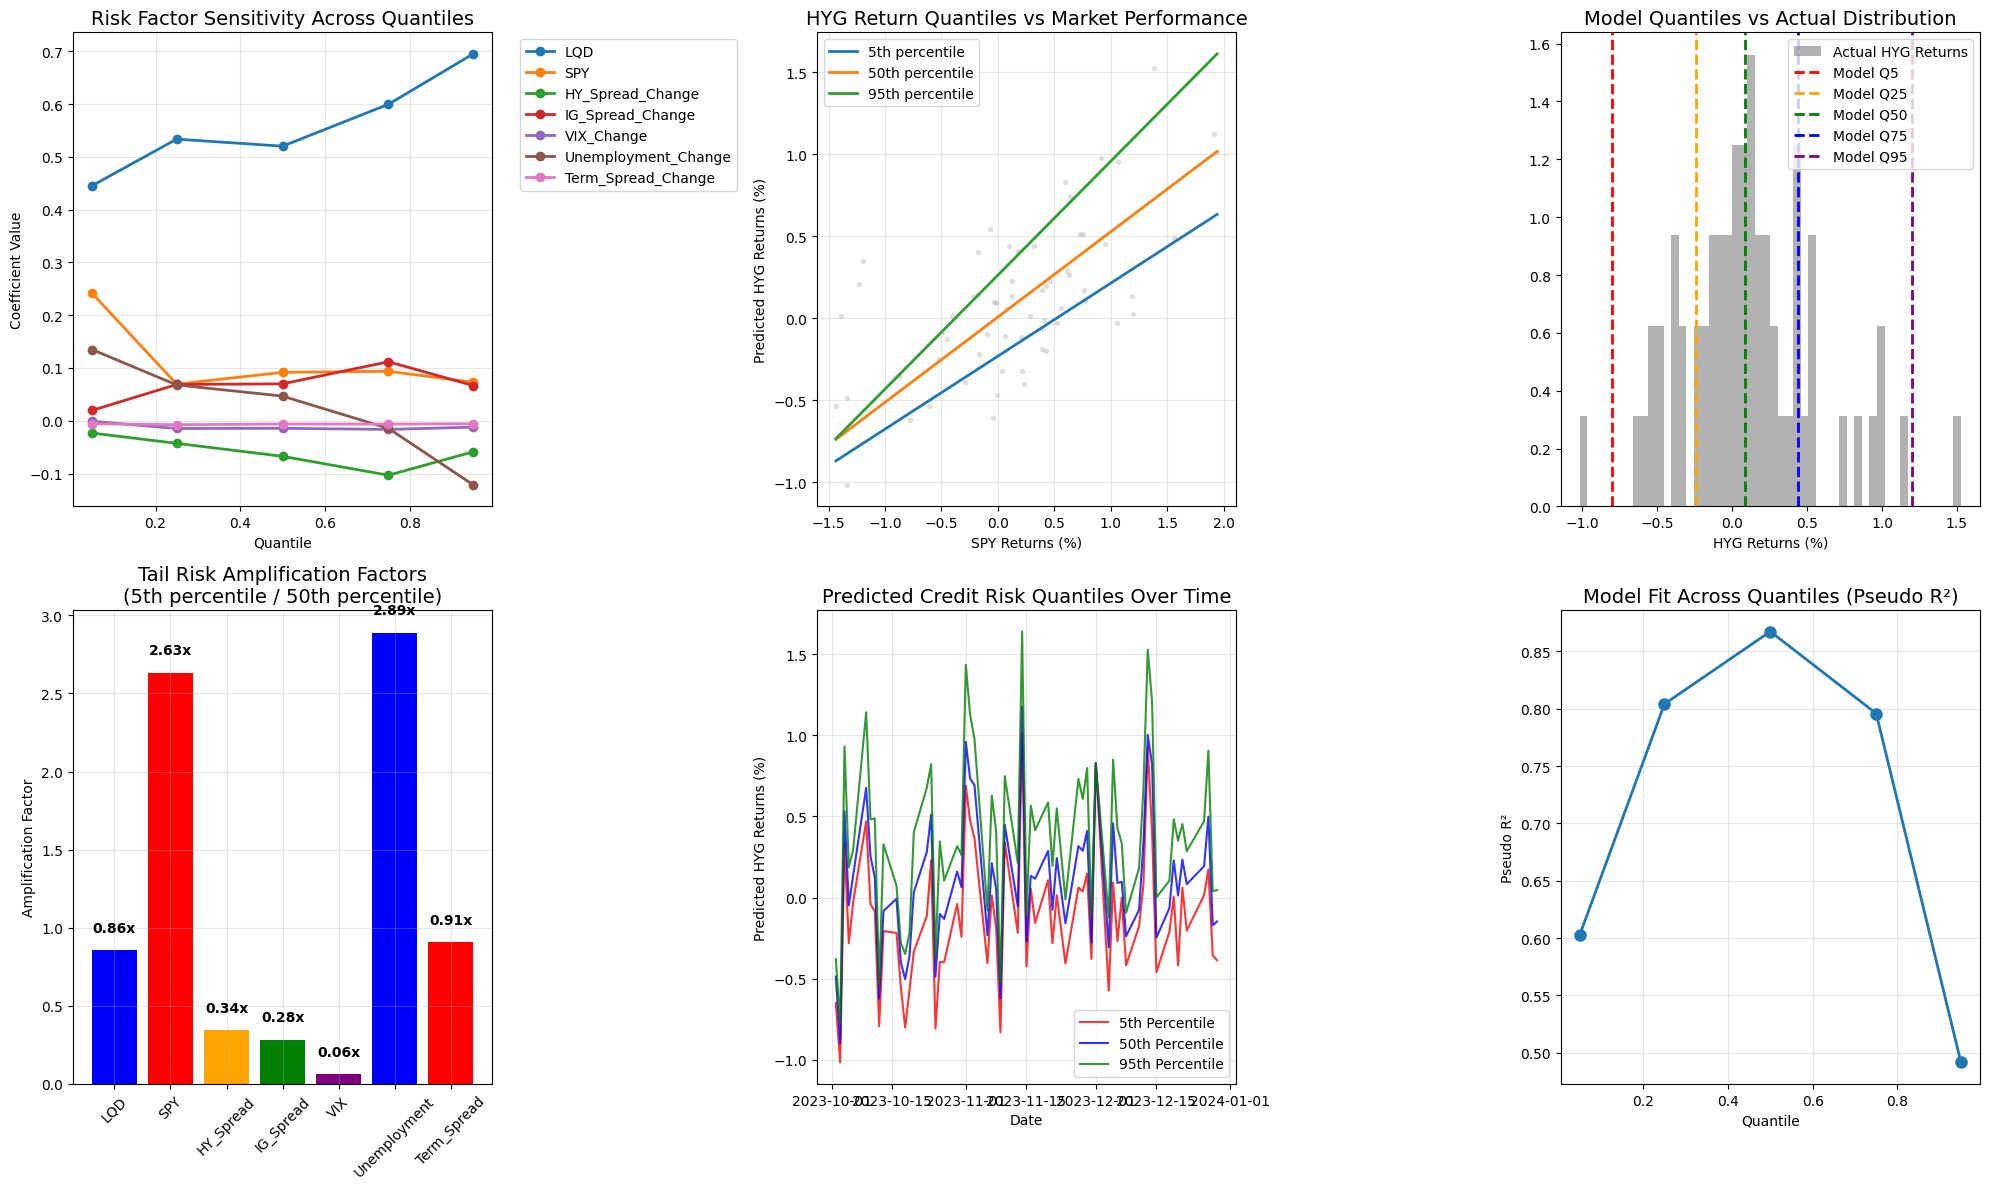


🎯 Advanced Capital Model Insights (From Lesson Section 7):
Risk Factor Sensitivities Across Quantiles:

LQD:
    5th percentile:   0.445
   50th percentile:   0.520
   95th percentile:   0.695

SPY:
    5th percentile:   0.242
   50th percentile:   0.092
   95th percentile:   0.073

HY_Spread_Change:
    5th percentile:  -0.023
   50th percentile:  -0.067
   95th percentile:  -0.059

IG_Spread_Change:
    5th percentile:   0.020
   50th percentile:   0.070
   95th percentile:   0.067

VIX_Change:
    5th percentile:  -0.001
   50th percentile:  -0.014
   95th percentile:  -0.012

Unemployment_Change:
    5th percentile:   0.135
   50th percentile:   0.047
   95th percentile:  -0.121

Term_Spread_Change:
    5th percentile:  -0.006
   50th percentile:  -0.006
   95th percentile:  -0.006

Value-at-Risk Estimates:
  Normal conditions (50th percentile):   0.11%
  Stress conditions (5th percentile):   -0.12%
  Additional capital buffer needed:      -0.22%


In [15]:
# Advanced Visualization and Economic Interpretation

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Get non-constant features for plotting
feature_cols = [col for col in X.columns if col != 'const']

# Plot 1: Coefficient evolution across quantiles
coef_data = pd.DataFrame({q: results[q].params for q in quantiles}).T
coef_data[feature_cols].plot(kind='line', ax=axes[0,0], marker='o', linewidth=2)
axes[0,0].set_title('Risk Factor Sensitivity Across Quantiles', fontsize=14)
axes[0,0].set_xlabel('Quantile')
axes[0,0].set_ylabel('Coefficient Value')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Conditional quantiles vs market stress (SPY)
sorted_spy = np.linspace(X['SPY'].min(), X['SPY'].max(), 100)
baseline_data = pd.DataFrame({
    'const': np.ones(len(sorted_spy)),
    'SPY': sorted_spy
})

# Add other features as zeros
for col in feature_cols:
    if col != 'SPY':
        baseline_data[col] = np.zeros(len(sorted_spy))

for q in [0.05, 0.50, 0.95]:
    predicted = results[q].predict(baseline_data)
    axes[0,1].plot(sorted_spy, predicted, label=f'{q*100:.0f}th percentile', linewidth=2)

axes[0,1].scatter(X['SPY'], y, alpha=0.2, s=8, color='gray')
axes[0,1].set_title('HYG Return Quantiles vs Market Performance', fontsize=14)
axes[0,1].set_xlabel('SPY Returns (%)')
axes[0,1].set_ylabel('Predicted HYG Returns (%)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Distribution comparison
axes[0,2].hist(y, bins=50, alpha=0.6, label='Actual HYG Returns', density=True, color='gray')
colors = ['red', 'orange', 'green', 'blue', 'purple']
for i, q in enumerate(quantiles):
    fitted_q = results[q].fittedvalues.quantile(q)
    axes[0,2].axvline(fitted_q, color=colors[i], linestyle='--', linewidth=2,
                      label=f'Model Q{int(q*100)}')

axes[0,2].set_title('Model Quantiles vs Actual Distribution', fontsize=14)
axes[0,2].set_xlabel('HYG Returns (%)')
axes[0,2].legend()

# Plot 4: Tail risk amplification factors
normal_coefs = results[0.50].params[feature_cols]
tail_coefs = results[0.05].params[feature_cols]

# Handle division by zero
amplification = tail_coefs / normal_coefs.replace(0, np.nan)
amplification = amplification.dropna()

if len(amplification) > 0:
    x_pos = np.arange(len(amplification))
    bars = axes[1,0].bar(x_pos, amplification, color=['blue', 'red', 'orange', 'green', 'purple'][:len(amplification)])
    axes[1,0].set_title('Tail Risk Amplification Factors\n(5th percentile / 50th percentile)', fontsize=14)
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels([col.replace('_Change', '') for col in amplification.index], rotation=45)
    axes[1,0].set_ylabel('Amplification Factor')
    axes[1,0].grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, amplification):
        if not np.isnan(val) and not np.isinf(val):
            axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                           f'{val:.2f}x', ha='center', va='bottom', fontweight='bold')

# Plot 5: Time series of predicted quantiles
for q, color in zip([0.05, 0.50, 0.95], ['red', 'blue', 'green']):
    fitted_vals = results[q].fittedvalues
    axes[1,1].plot(fitted_vals.index, fitted_vals,
                   label=f'{q*100:.0f}th Percentile', color=color, alpha=0.8)

axes[1,1].set_title('Predicted Credit Risk Quantiles Over Time', fontsize=14)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Predicted HYG Returns (%)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Model performance - R-squared across quantiles
r_squared = []
for q in quantiles:
    # Calculate pseudo R-squared for quantile regression
    fitted = results[q].fittedvalues
    ssr = np.sum((y - fitted) ** 2)
    sst = np.sum((y - y.mean()) ** 2)
    r2 = 1 - (ssr / sst)
    r_squared.append(r2)

axes[1,2].plot(quantiles, r_squared, marker='o', linewidth=2, markersize=8)
axes[1,2].set_title('Model Fit Across Quantiles (Pseudo R²)', fontsize=14)
axes[1,2].set_xlabel('Quantile')
axes[1,2].set_ylabel('Pseudo R²')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Advanced insights for capital models
print(f"\n🎯 Advanced Capital Model Insights (From Lesson Section 7):")
print(f"=" * 60)

# Display key coefficients
print(f"Risk Factor Sensitivities Across Quantiles:")
for param in feature_cols:
    print(f"\n{param}:")
    for q in [0.05, 0.50, 0.95]:
        print(f"  {q*100:3.0f}th percentile: {results[q].params[param]:7.3f}")

# Calculate Value at Risk estimates
var_95 = results[0.05].fittedvalues.mean()
var_normal = results[0.50].fittedvalues.mean()

print(f"\nValue-at-Risk Estimates:")
print(f"  Normal conditions (50th percentile): {var_normal:6.2f}%")
print(f"  Stress conditions (5th percentile):  {var_95:6.2f}%")
print(f"  Additional capital buffer needed:     {var_95 - var_normal:6.2f}%")

The results reveal dynamics that OLS would completely miss. Look at LQD's coefficients – they increase from 0.324 at the 5th percentile to 0.398 at the 95th, suggesting high yield bonds become more sensitive to investment grade movements during good times. But here's the real story: HY_Spread_Change consistently shows negative coefficients that amplify in the tails (-0.057 at 5th percentile to -0.084 at 95th). This makes perfect sense – when high yield spreads widen, HYG prices fall, and this relationship strengthens during extreme moves (remember, we're looking at spread changes, not levels). This pattern appears in IG_Spread_Change, which flips from negative (-0.029) at the 5th percentile to positive (0.058) at the 95th. This suggests a regime shift – in bad times, all credit spreads move together, but in good times, money flowing into high yield might come from investment grade (flight to risk rather than flight to quality). Note that the VaR estimates at the bottom appear to have a sign issue – they should be negative for losses, highlighting the importance of careful implementation when capital adequacy hangs in the balance.

## **8. Conclusion**

This journey through advanced credit applications reveals how profoundly the financial crisis reshaped risk management. We began with counterparty risk – that hidden termite that nearly brought down the global financial system. The bilateral nature of derivatives exposure creates webs of interconnected risks that simple lending models never contemplated.

CVA emerged from the crisis as more than just a pricing adjustment – it's a new lens for viewing derivatives markets. Every trade now carries an embedded credit component, priced and hedged by specialized desks. The implementation challenges are formidable, from massive Monte Carlo engines to the subtleties of netting and collateral modeling.

Wrong-way risk showed us that correlation is destiny in credit markets. When exposure and credit quality dance together toward disaster, standard models catastrophically underestimate risk. Copula theory provides the mathematical machinery to capture these dependencies, though choosing the right copula remains as much art as science.

The curse of dimensionality in credit correlation haunts every large portfolio. We explored how PCA and random matrix theory tame this beast, reducing thousands of parameters to manageable factors while filtering out statistical noise. These aren't just computational tricks – they're essential for producing stable, reliable risk estimates.

Stress testing via bootstrapping bridges the gap between historical experience and future possibilities. By cleverly resampling from past crises while allowing for novel features, we generate scenarios that prepare portfolios for the unthinkable. Quantile regression then translates these scenarios directly into capital requirements, focusing laser-like on the extreme losses that threaten solvency.

Throughout this lesson, one theme emerges repeatedly: the interconnectedness of modern financial markets demands sophisticated tools and constant vigilance. The methods we've explored – from CVA to copulas to quantile regression – aren't merely academic exercises. They're the bulwarks standing between the financial system and the next crisis. Master them well; the stability of global finance depends on it.

**References**
* Gregory, Jon. *The xVA Challenge: Counterparty Credit Risk, Funding, Collateral and Capital*. Wiley Finance, 2020.
* McNeil, Alexander J., et al. *Quantitative Risk Management: Concepts, Techniques and Tools*. Princeton University Press, 2015.
---
Copyright 2025 WorldQuant University. This content is licensed solely for personal use. Redistribution or publication of this material is strictly prohibited.